Data Visualization Project
Dataset: Adult Income (UCI)
Мета роботи:
- Виконати очищення даних (Data Cleaning)
- Провести аналіз даних
- Побудувати різні типи графіків
- Виявити залежності між змінними

In [1]:
#Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
#Завантаження датасету
df = pd.read_csv("adult.data", header=None)

df.columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race",
    "sex", "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

Data Cleaning

In [3]:
#Обробка пропущених значень
df = df.replace(" ?", np.nan)
df = df.dropna()

In [4]:
#Перевірка типів
df.info()

<class 'pandas.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   fnlwgt          30162 non-null  int64
 3   education       30162 non-null  str  
 4   education-num   30162 non-null  int64
 5   marital-status  30162 non-null  str  
 6   occupation      30162 non-null  str  
 7   relationship    30162 non-null  str  
 8   race            30162 non-null  str  
 9   sex             30162 non-null  str  
 10  capital-gain    30162 non-null  int64
 11  capital-loss    30162 non-null  int64
 12  hours-per-week  30162 non-null  int64
 13  native-country  30162 non-null  str  
 14  income          30162 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [5]:
#Перетворення
df["age"] = df["age"].astype(int)
df["hours-per-week"] = df["hours-per-week"].astype(int)

Візуалізація

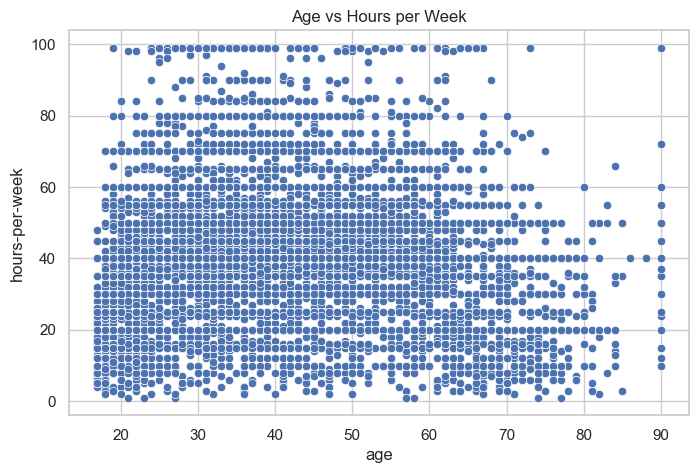

In [13]:
#Scatter plot (залежність числових змінних)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="age", y="hours-per-week")
plt.title("Age vs Hours per Week")
plt.show()

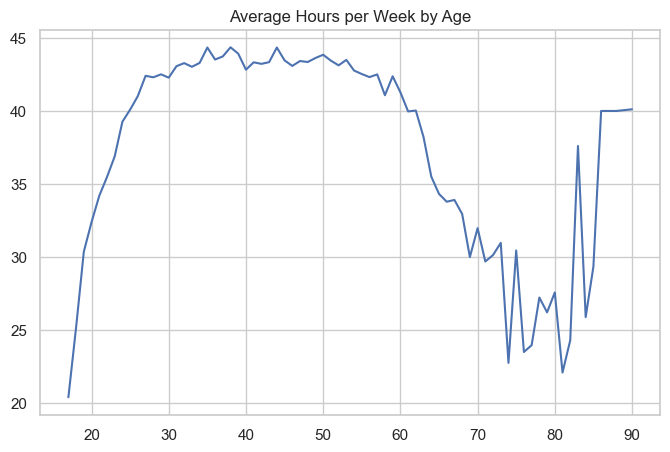

In [14]:
#Line plot (усереднення)
df_grouped = df.groupby("age")["hours-per-week"].mean()
plt.figure(figsize=(8,5))
plt.plot(df_grouped.index, df_grouped.values)
plt.title("Average Hours per Week by Age")
plt.show()

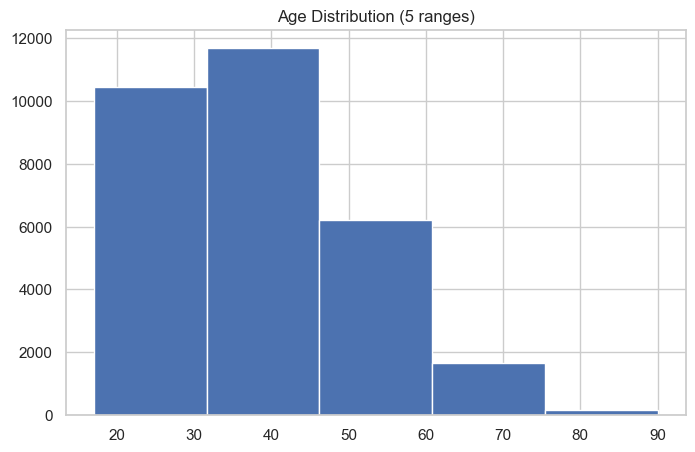

In [15]:
#Гістограма (5 діапазонів)
bins = 5
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=bins)
plt.title("Age Distribution (5 ranges)")
plt.show()

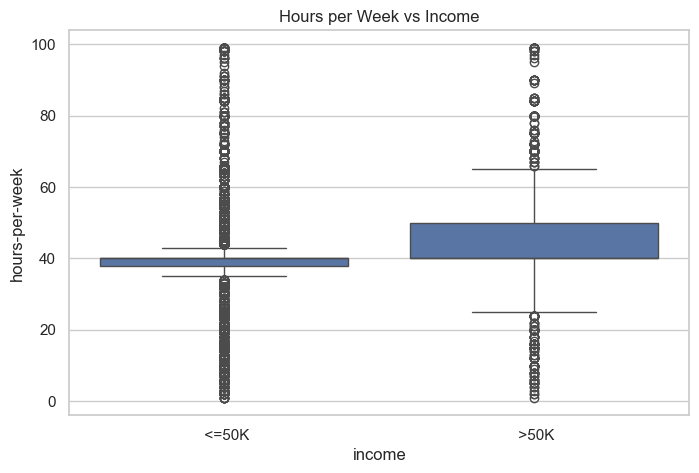

In [16]:
#Boxplot (із статті Medium)
plt.figure(figsize=(8,5))
sns.boxplot(x="income", y="hours-per-week", data=df)
plt.title("Hours per Week vs Income")
plt.show()

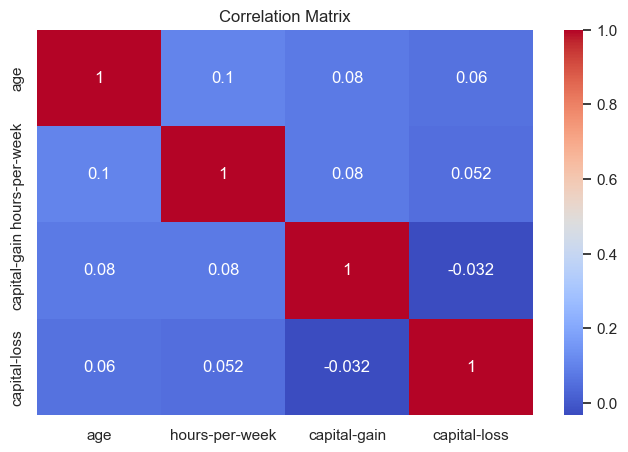

In [17]:
#Heatmap (кореляція)
corr = df[["age", "hours-per-week", "capital-gain", "capital-loss"]].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

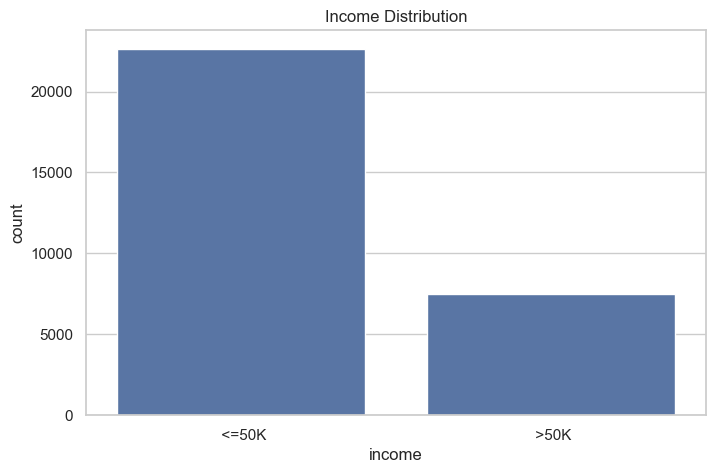

In [18]:
#Countplot (категоріальні дані)
plt.figure(figsize=(8,5))
sns.countplot(x="income", data=df)
plt.title("Income Distribution")
plt.show()

Загальні висновки:

- Основна частина людей працює близько 40 годин на тиждень  
- Вік не має сильної залежності з робочими годинами  
- Люди з вищим доходом (>50K) працюють більше  
- Дані мають нерівномірний розподіл (особливо capital-gain)  
- Сильних кореляцій між змінними не виявлено
- Люди старшого віку працюютьменше
- Вищий дохід пов’язаний з більшими робочими годинами
- Capital-gain має сильну асиметрію